<img src="imagens/clusterizacao_de_clientes.png" width="100%">

<h1 style="font-size: 56px; font-weight: 900; letter-spacing: 0px; margin: 0;"><span style="color: #f66001;">SEGMENTAÇÃO</span> DE CLIENTES COM MACHINE LEARNING</h1>
<br>
<p>Suponha que uma empresa deseja desenvolver campanhas de marketing junto aos seus clientes para alavancar seu faturamento. Essa é uma situação muito comum nas organizações, mas o sucesso de uma campanha está diretamente ligado ao direcionamento correto para um público alvo.
<br>
Neste trabalho desenvolvido em R e utilizando o algoritmo de Machine Learning K-Means, traço os perfis de clientes que uma loja de shopping possui, para que ela possa realizar ações de marketing que façam sentido para cada um de seus públicos.
</p>
<br>
Ilustração de capa: Form From

<div style="background:#fff7f7;padding:6px 26px;margin:18px 0;">
<p style="font-weight:800;margin-bottom:4px;">ROTEIRO</p>
<div style="color:#2D2A32;line-height:1.7;"><ol style="color:#2D2A32;line-height:1.7;">
<li>Bibliotecas</li>
<li>Conjunto de dados</li>
<li>Preparação dos dados</li>
<li>Definindo o número de clusters</li>
<li>Juntando os dados</li>
<li>Análise descritiva dos grupos</li>
</ol></div></div>

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">1. BIBLIOTECAS</h1>
Sem muito segredo, carregamos as bibliotecas comumente utilizadas nesse tipo de trabalho de clusterização não hierárquico. No código abaixo, cada linha é seguida de um comentário explicando ao que ela se refere.

In [17]:
library(tidyverse)  # pacote para manipulação de dados
library(cluster)    # algoritmo de cluster
library(factoextra) # algoritmo de cluster e visualização
library(fpc)        # algoritmo de cluster e visualização
library(gridExtra)      # para a funcao grid arrange
library(readxl)     # leitura dos dados

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">2. CONJUNTO DE DADOS</h1>
Com as bibliotecas carregadas, importamos a base de dados “clientes” e a visualizei, verificando o número de variáveis e de observações.

In [18]:
clientes <- read.table('data/customers.csv',sep = ",", header = T, dec = ",")

In [19]:
head(clientes)

,CustomerID,Gender,Age,Annual.Income..k..,Spending.Score..1.100.
,<int>,<chr>,<int>,<int>,<int>
1,1,Male,19,15,39
2,2,Male,21,15,81
3,3,Female,20,16,6
4,4,Female,23,16,77
5,5,Female,31,17,40
6,6,Female,22,17,76


<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">3. PREPARAÇÃO DOS DADOS</h1>

In [20]:
rownames(clientes) <- clientes[,1]

In [21]:
head(clientes)

,CustomerID,Gender,Age,Annual.Income..k..,Spending.Score..1.100.
,<int>,<chr>,<int>,<int>,<int>
1,1,Male,19,15,39
2,2,Male,21,15,81
3,3,Female,20,16,6
4,4,Female,23,16,77
5,5,Female,31,17,40
6,6,Female,22,17,76


In [22]:
clientes <- clientes[,-c(1,2,3)]

In [23]:
clientes <- clientes %>% rename(salario.anual=Annual.Income..k..,
                    score=Spending.Score..1.100.
                    )

In [24]:
head(clientes)

,salario.anual,score
,<int>,<int>
1,15,39
2,15,81
3,16,6
4,16,77
5,17,40
6,17,76


Esse dataframe possui uma coluna “CustomerID” e as variáveis “Gender”, “Age”, “Annual Income” e “Spending Score”.

Mantivemos no dataframe apenas as colunas que iremos utilizar para o agrupamento, que serão “Annual Income” e “Spending Score”. Como o foco é definir perfis de consumo, não utilizaremos dados de gênero e idade. Ambas as colunas mantidas foram renomeadas para a tradução em português, para que ficasse mais intuitiva a visualização nos gráficos.

Embora seja um dataframe simples, a metodologia não muda quando se trata de uma ABT com mais variáveis.

In [25]:
clientes.padronizado <- scale(clientes)

In [26]:
head(clientes.padronizado)

,salario.anual,score
1,-1.734646,-0.4337131
2,-1.734646,1.1927111
3,-1.696572,-1.7116178
4,-1.696572,1.0378135
5,-1.658498,-0.3949887
6,-1.658498,0.9990891


Repare que eu criei um novo dataframe “clientes.padronizado”, que recebe os dados de “clientes”, mas já com os dados convertidos em uma mesma escala.

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">4. DEFININDO O NÚMERO DE CLUSTERS</h1>
Na clusterização, um grande objetivo é manter a menor variância dentro dos grupos, os deixando mais homogêneos. Para definir o número de clusters a serem considerados, utilizamos o “Elbow Method”, plotando os dados em um gráfico de linhas onde no eixo X estão o número de clusters e no eixo Y, o somatório das variâncias.

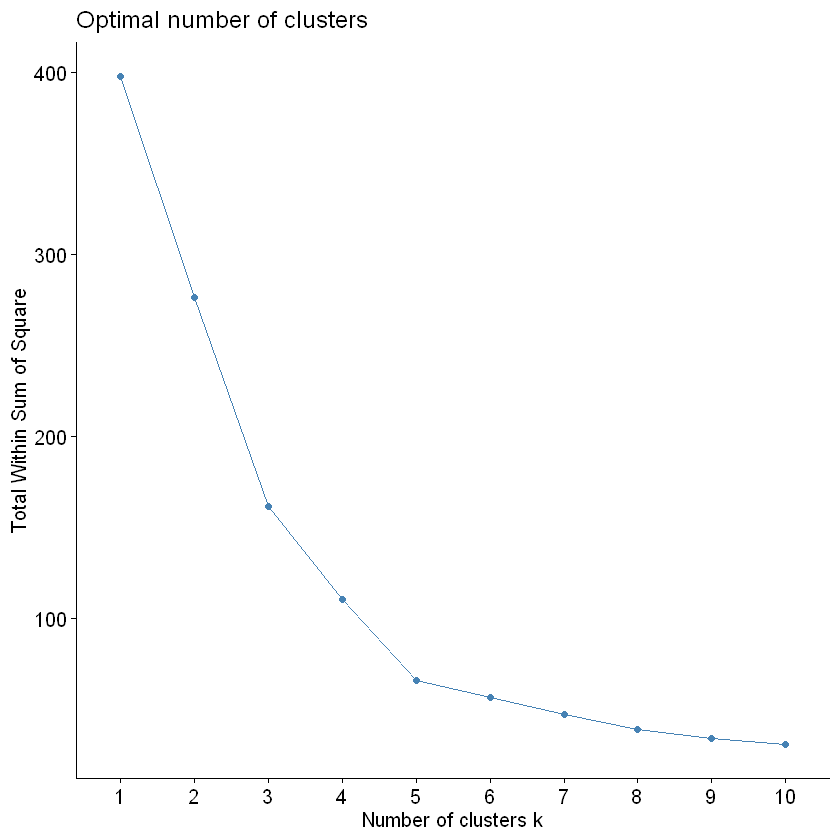

In [27]:
fviz_nbclust(clientes.padronizado, FUN = hcut, method = "wss")

Repare que quanto mais eu aumento o número de clusters, mais eu diminuo a variância dentro deles. No entanto, após o número 5 a queda é menos acentuada, o que demonstra que a partir dali eu estou dividindo em grupos diferentes clientes que possuem perfis parecidos.

Em tradução, o “Elbow Method” significa “Método do Cotovelo”, pois consideramos o número de clusters aquele que aparece bem na volta da curva, como um cotovelo mesmo. Nesse caso, inicialmente o 5 parece ser o número ideal a ser utilizado.

Mas para fins de estudos, vamos testar os dados com clusters que vão de 3 a 6, e plotaremos em um gráfico para conseguirmos visualizar melhor a divisão.

In [28]:
# testando de 3 a 6 centros para visualizar a melhor divisão

clientes.k3 <- kmeans(clientes.padronizado,centers=3)
clientes.k4 <- kmeans(clientes.padronizado,centers=4)
clientes.k5 <- kmeans(clientes.padronizado,centers=5)
clientes.k6 <- kmeans(clientes.padronizado,centers=6)

Com meus dados divididos em clusters de 3 a 6, criamos os gráficos e logo em seguida utilizamos a função “grid.arrange” para visualizarmos e compararmos todos lado a lado.

In [29]:
# gráficos

G1 <- fviz_cluster(clientes.k3, geom="point", data=clientes.padronizado) + ggtitle("k=3")
G2 <- fviz_cluster(clientes.k4, geom="point", data=clientes.padronizado) + ggtitle("k=4")
G3 <- fviz_cluster(clientes.k5, geom="point", data=clientes.padronizado) + ggtitle("k=5")
G4 <- fviz_cluster(clientes.k6, geom="point", data=clientes.padronizado) + ggtitle("k=6")


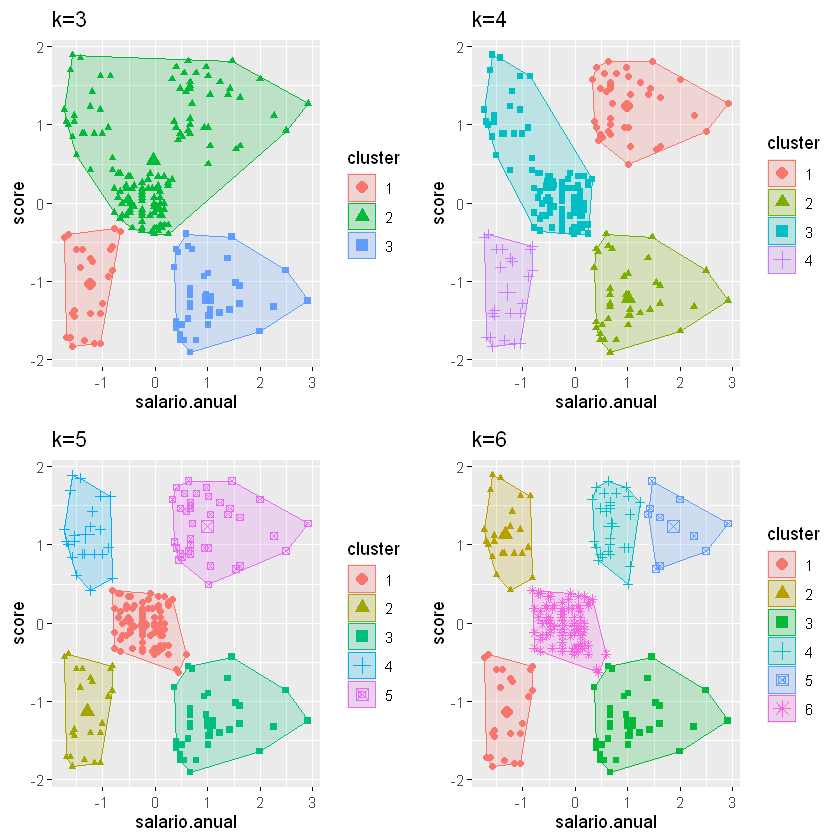

In [30]:
grid.arrange(G1,G2,G3,G4, nrow=2)

Perceba como os dados que foram divididos em 3 e 4 clusters possuem grupos grandes, com clientes diferentes que claramente elevam a variância dentro de cada um deles. Já nos dados que foram divididos em 5 e 6 clusters os grupos estão abrangendo clientes que são parecidos entre si, em uma delimitação que faz mais sentido.

Aqui, seria possível utilizar 5 ou 6 clusters. <b>No entanto, como verificamos com o “Elbow Method” que o somatório das variâncias de 5 para 6 cai muito pouco, escolhemos então utilizar 5 clusters.</b>

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">5. JUNTANDO OS DADOS</h1>
Após decidir utilizar o agrupamento do “clientes.k5”, importamos novamente a base de dados inicial e concatenamos, criando uma nova coluna que se refere a qual grupo aquele cliente pertence.

In [33]:
# juntando os dados

clientes2 <- read.table('data/customers.csv',sep = ",", header = T, dec = ",")
clientesfit <- data.frame(clientes.k5$cluster)

clientes.final <- cbind(clientes2,clientesfit)

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">6. ANÁLISE DESCRITIVA DOS GRUPOS</h1>
Definido qual o grupo de cada cliente, podemos agora realizar uma análise descritiva dos grupos, para saber qual a média de salário anual e qual a média de consumo de cada um deles.

In [34]:
# análise descritiva dos grupos

## média das variaveis

mediagrupo <- clientes.final %>% 
  group_by(clientes.k5.cluster) %>% 
  summarise(n=n(),
            salario.anual=mean(Annual.Income..k..),
            score=mean(Spending.Score..1.100.)
            )
mediagrupo

clientes.k5.cluster,n,salario.anual,score
<int>,<int>,<dbl>,<dbl>
1,81,55.29630,49.51852
2,23,26.30435,20.91304
3,35,88.20000,17.11429
4,22,25.72727,79.36364
5,39,86.53846,82.12821


Como interpretamos os dados:

<b>Grupo 1:</b> Ganho intermediário e gasto também intermediário;<br>
<b>Grupo 2:</b> Ganha pouco e gasta pouco;<br>
<b>Grupo 3:</b> Ganha muito e gasta pouco;<br>
<b>Grupo 4:</b> Ganha pouco e gasta muito;<br>
<b>Grupo 5:</b> Ganha muito e gasta muito.<br>